# Clonotrace: Clone-Level Transcriptomic Analysis

This notebook demonstrates the full Clonotrace pipeline using a **hematopoiesis dataset** (34,782 cells, 3 timepoints). It mirrors the R vignette (`Clonotrace.Rmd`) step by step.

**Key concepts:**
- **Clone fate mapping**: Propagate sparse barcode labels across a cell graph via label spreading
- **Clonewise distance**: Compute transcriptomic distances between clones using graph-based optimal transport or nearest-neighbor approximation
- **Clone profiles**: Cluster clones by transcriptomic similarity and project back to cells
- **Profile DEG**: Identify differentially expressed genes specific to a clone profile within a cell cluster

## Setup

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.io import mmread
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import clonotrace as ct
from clonotrace.visualization import dimplot, scatterpie, umap_from_knn, mds_from_knn
from clonotrace.coembed import cell_clone_coembed

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Load Data

The hematopoiesis dataset was extracted from the Seurat RDS object. It contains:
- **PCA embeddings** (50 components)
- **UMAP coordinates** (2D)
- **Cell metadata** (clone, cluster, celltype, timepoint)
- **Expression matrix** (genes × cells, sparse)

In [2]:
DATA_DIR = "real_data"

pca = pd.read_csv(f"{DATA_DIR}/pca.csv", index_col=0)
umap = pd.read_csv(f"{DATA_DIR}/umap.csv", index_col=0)
cell_meta = pd.read_csv(f"{DATA_DIR}/cell_meta.csv", index_col=0)

# Expression matrix (genes × cells)
exprs = mmread(f"{DATA_DIR}/exprs.mtx").tocsr()
gene_names = open(f"{DATA_DIR}/gene_names.txt").read().splitlines()
cell_names_exprs = open(f"{DATA_DIR}/cell_names_exprs.txt").read().splitlines()

print(f"Cells: {pca.shape[0]}, PCA dims: {pca.shape[1]}")
print(f"Genes: {len(gene_names)}, Expression matrix: {exprs.shape}")
print(f"Cell metadata columns: {list(cell_meta.columns)}")

Cells: 34782, PCA dims: 50
Genes: 25289, Expression matrix: (25289, 34782)
Cell metadata columns: ['Cell.type.annotation', 'Time.point', 'clone', 'cluster']


## Data Overview

Visualize cell types and clusters on the UMAP embedding.

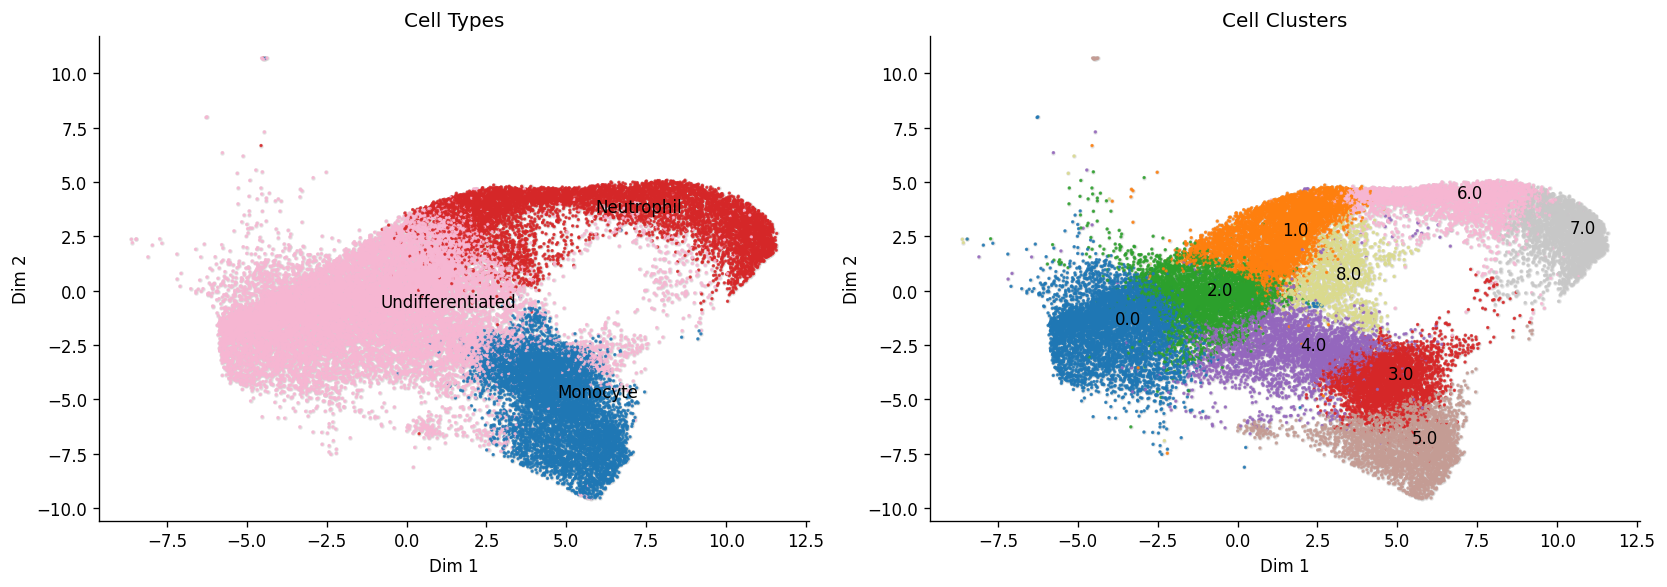

In [3]:
umap.columns = ["umap_1", "umap_2"]
cell_meta = cell_meta.assign(umap_1=umap["umap_1"].values, umap_2=umap["umap_2"].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cell type UMAP
if "Cell.type.annotation" in cell_meta.columns:
    dimplot(umap, cell_meta, color_by="Cell.type.annotation", ax=axes[0], s=1)
    axes[0].set_title("Cell Types")

# Cluster UMAP
if "cluster" in cell_meta.columns:
    dimplot(umap, cell_meta, color_by="cluster", ax=axes[1], s=1)
    axes[1].set_title("Cell Clusters")

plt.tight_layout()
plt.show()

## 1. Clone Label Spreading

### 1.1 Build cell kNN graph and prepare clone labels

In [4]:
# Build kNN graph (k=30, connectivity mode)
cell_knn = ct.embedding2knn(pca.values, k=30)
cell_knn = ct.compute_transition(cell_knn)

# Identify expanded clones (>= 10 cells)
clone_size = cell_meta.groupby("clone").size().reset_index(name="count")
expanded_clones = clone_size[clone_size["count"] >= 10]["clone"].values

print(f"Total clones: {len(clone_size)}")
print(f"Expanded clones (>= 10 cells): {len(expanded_clones)}")

Total clones: 8108
Expanded clones (>= 10 cells): 802


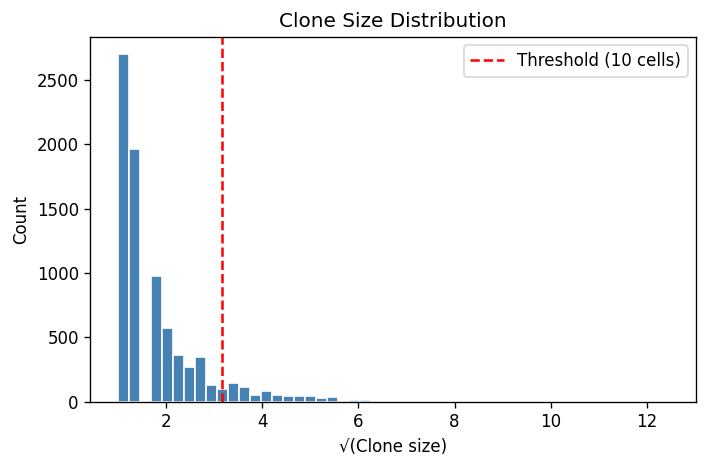

In [5]:
# Clone size histogram
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.sqrt(clone_size["count"]), bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("√(Clone size)")
ax.set_ylabel("Count")
ax.set_title("Clone Size Distribution")
ax.axvline(np.sqrt(10), color="red", linestyle="--", label="Threshold (10 cells)")
ax.legend()
plt.tight_layout()
plt.show()

### 1.2 Label spreading bootstrap

Propagate clone labels across the cell graph with bootstrap resampling to estimate assignment stability (deviance).

In [6]:
# Prepare labels: expanded clones keep their name, others become NaN
cell_clone = cell_meta["clone"].copy()
cell_clone[~cell_clone.isin(expanded_clones)] = np.nan

# Run label spreading bootstrap
# Uses float32 + threading for speed; n_jobs=-1 uses all cores
np.random.seed(42)
result = ct.label_spreading_bootstrap(
    cell_knn, cell_clone.values,
    alpha=0.6, sample_rate=0.8, sample_n=48, n_jobs=-1
)

cell_clone_prob_raw = result["prob"]
deviance = result["deviance"]

print(f"Cell-clone probability matrix: {cell_clone_prob_raw.shape}")
print(f"Deviance range: [{deviance.min():.4f}, {deviance.max():.4f}]")

Cell-clone probability matrix: (34782, 802)
Deviance range: [0.0113, 0.5971]


### 1.3 Deviance analysis

Cells with high deviance have unstable clone assignments across bootstrap replicates. We filter at deviance < 0.3.

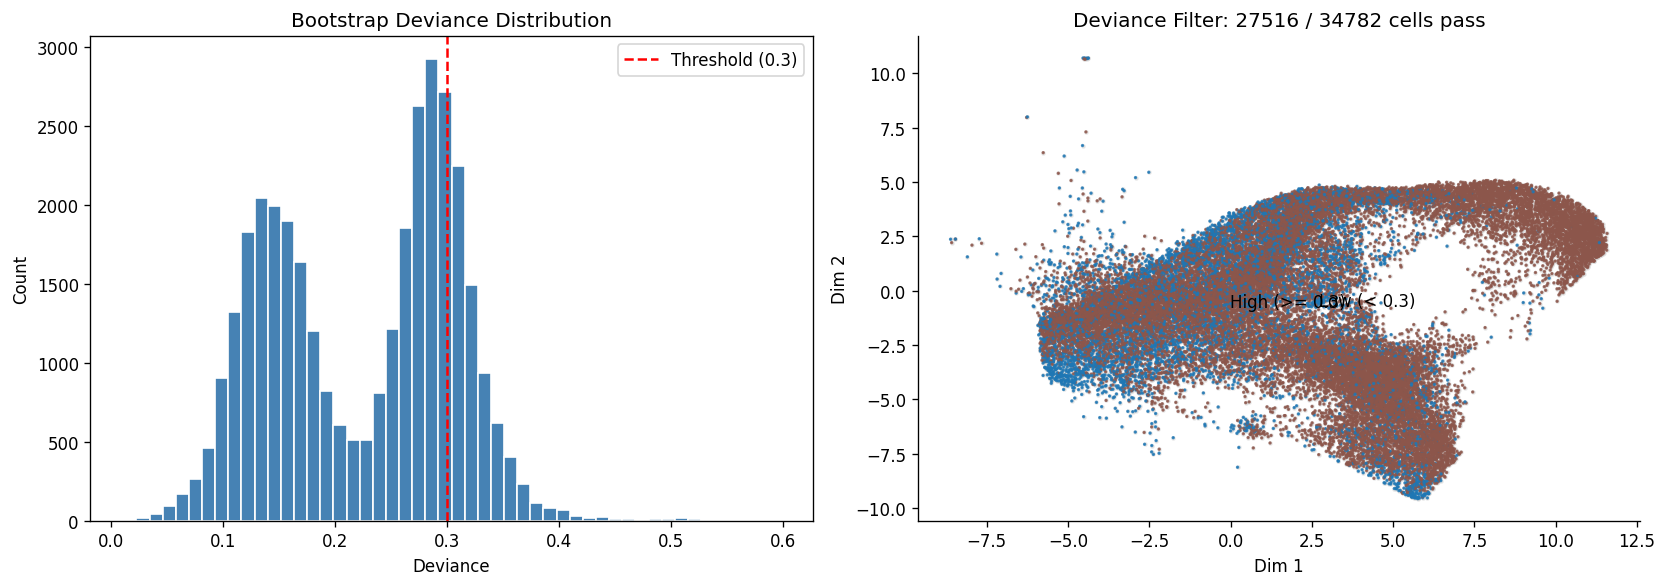

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Deviance histogram
axes[0].hist(deviance, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0.3, color="red", linestyle="--", label="Threshold (0.3)")
axes[0].set_xlabel("Deviance")
axes[0].set_ylabel("Count")
axes[0].set_title("Bootstrap Deviance Distribution")
axes[0].legend()

# High-deviance cells on UMAP
dev_label = np.where(deviance < 0.3, "Low (< 0.3)", "High (>= 0.3)")
cell_meta["deviance_group"] = dev_label
dimplot(umap, cell_meta, color_by="deviance_group", ax=axes[1], s=1)
axes[1].set_title(f"Deviance Filter: {(deviance < 0.3).sum()} / {len(deviance)} cells pass")

plt.tight_layout()
plt.show()

### 1.4 Filter and sparsify

In [8]:
# Filter cells with low deviance
keep_mask = deviance < 0.3
cell_clone_prob = cell_clone_prob_raw[keep_mask]

# Row-normalize
row_sums = cell_clone_prob.sum(axis=1, keepdims=True)
row_sums = np.maximum(row_sums, 1e-12)
cell_clone_prob = cell_clone_prob / row_sums

# Sparsify (keep 90% mass per row and column)
cell_clone_prob = ct.mat_sparsify(cell_clone_prob, row_mass=0.9, col_mass=0.9)

# Re-normalize and convert to sparse
row_sums = cell_clone_prob.sum(axis=1, keepdims=True)
row_sums = np.maximum(row_sums, 1e-12)
cell_clone_prob = cell_clone_prob / row_sums
cell_clone_prob = sp.csr_matrix(cell_clone_prob)

# Track cell and clone names
filtered_cells = cell_meta.index[keep_mask]
clone_names = expanded_clones  # column names match factorized order

print(f"After filtering: {cell_clone_prob.shape[0]} cells, {cell_clone_prob.shape[1]} clones")
print(f"Sparsity: {1 - cell_clone_prob.nnz / np.prod(cell_clone_prob.shape):.4f}")

After filtering: 27516 cells, 802 clones
Sparsity: 0.9554


### 1.5 Visualize clone smoothing

Example: clone assignment before vs. after label spreading.

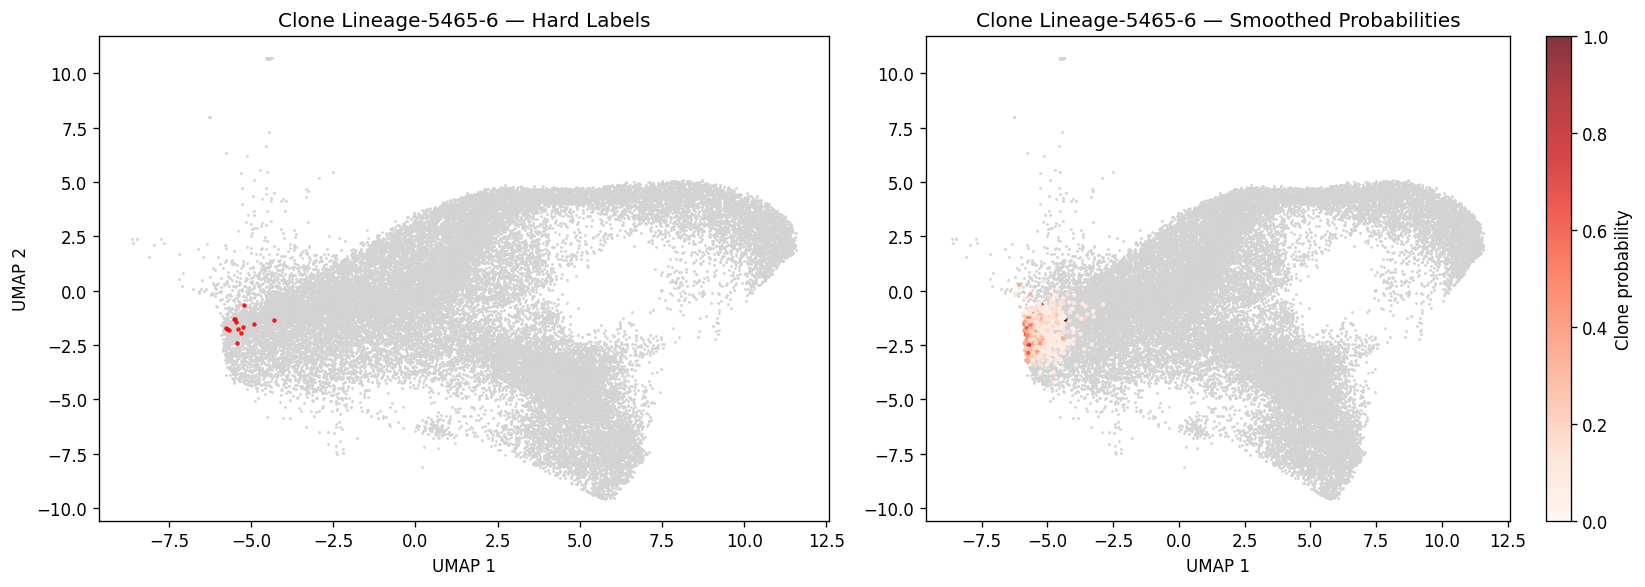

In [9]:
# Pick an example clone with clear signal
clone_masses = np.array(cell_clone_prob.sum(axis=0)).ravel()
example_idx = np.argmax(clone_masses)  # largest clone

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: hard labels (barcoded cells only)
hard_label = cell_meta["clone"].copy()
is_example = (hard_label == clone_names[example_idx]).astype(float)
sc1 = axes[0].scatter(umap["umap_1"], umap["umap_2"], c="lightgrey", s=0.5)
mask = is_example > 0
axes[0].scatter(umap["umap_1"][mask], umap["umap_2"][mask], c="red", s=3, alpha=0.8)
axes[0].set_title(f"Clone {clone_names[example_idx]} — Hard Labels")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# After: soft probabilities from label spreading
soft_prob = np.zeros(len(cell_meta))
soft_prob[keep_mask] = np.array(cell_clone_prob[:, example_idx].todense()).ravel()
show_mask = soft_prob > 0.025
axes[1].scatter(umap["umap_1"], umap["umap_2"], c="lightgrey", s=0.5)
sc2 = axes[1].scatter(
    umap["umap_1"][show_mask], umap["umap_2"][show_mask],
    c=soft_prob[show_mask], cmap="Reds", s=3, alpha=0.8, vmin=0, vmax=1
)
plt.colorbar(sc2, ax=axes[1], label="Clone probability")
axes[1].set_title(f"Clone {clone_names[example_idx]} — Smoothed Probabilities")
axes[1].set_xlabel("UMAP 1")

plt.tight_layout()
plt.show()

## 2. Clonewise Transcriptomic Distance

Load pre-computed clone distances (graph-based optimal transport). Computing from scratch takes ~19 minutes.

In [10]:
clone_dis_raw = pd.read_csv(f"{DATA_DIR}/clone_graph_dis.tsv", sep="\t", index_col=0)
clone_dis = ct.long2square(
    clone_dis_raw, row_names_from="group1", col_names_from="group2",
    values_from="dis", symmetric=True
)
np.fill_diagonal(clone_dis, 0)
max_dis = np.nanmax(clone_dis)
clone_dis = np.nan_to_num(clone_dis, nan=max_dis)

print(f"Clone distance matrix: {clone_dis.shape}")
print(f"Distance range: [{clone_dis[clone_dis > 0].min():.4f}, {clone_dis.max():.4f}]")

Clone distance matrix: (802, 802)
Distance range: [0.0198, 0.2885]


## 3. Clone Embedding & Clustering

### 3.1 Louvain clustering on clone distance graph

In [11]:
np.random.seed(1230)
clone_cluster = ct.leiden_dis(
    clone_dis, k=20, resolution=0.5,
    if_umap=True, method="louvain"
)

# Add clone mass (total probability assigned to each clone)
clone_cluster["mass"] = np.array(cell_clone_prob.sum(axis=0)).ravel()
clone_cluster["clone"] = clone_names

n_clusters = len(clone_cluster["cluster"].unique())
print(f"Clone clusters: {n_clusters}")
print(f"Cluster sizes: {clone_cluster['cluster'].value_counts().to_dict()}")

/Users/yizhouw/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


Clone clusters: 9
Cluster sizes: {1: 165, 0: 126, 7: 125, 6: 86, 4: 72, 5: 67, 2: 66, 3: 56, 8: 39}


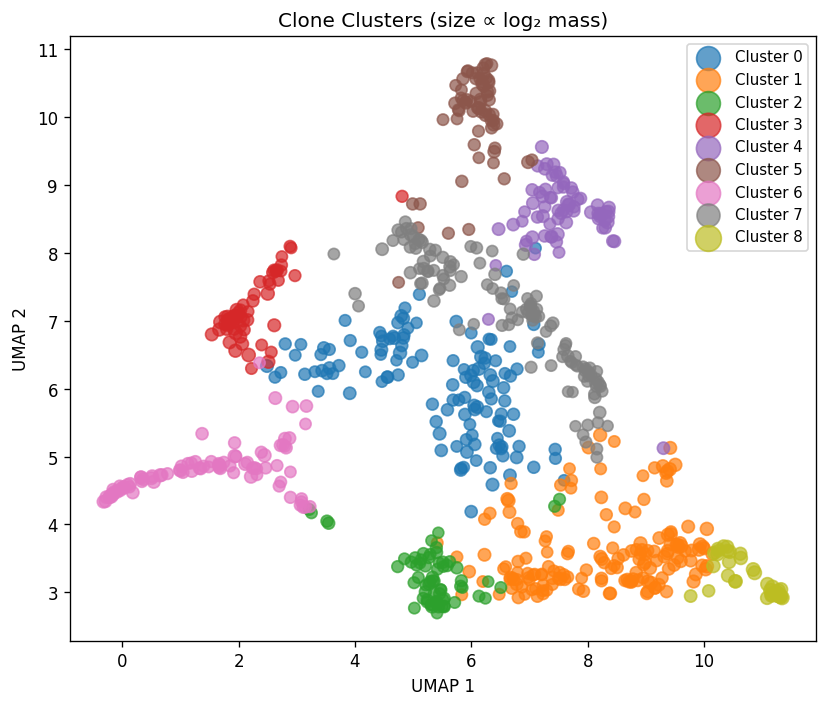

In [12]:
# Clone UMAP colored by cluster, sized by mass
fig, ax = plt.subplots(figsize=(7, 6))
for c in sorted(clone_cluster["cluster"].unique()):
    sub = clone_cluster[clone_cluster["cluster"] == c]
    ax.scatter(
        sub["umap1"], sub["umap2"],
        s=np.log2(sub["mass"] + 1) * 10,
        alpha=0.7, label=f"Cluster {c}"
    )
ax.legend(markerscale=2, fontsize=9)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Clone Clusters (size ∝ log₂ mass)")
plt.tight_layout()
plt.show()

### 3.2 Clone Diffusion Map

Compute diffusion map coordinates from the clone distance matrix, matching R's `diffusionMap::diffuse()`.

In [13]:
from clonotrace.visualization import diffusion_map

# Compute diffusion map from clone distance matrix
clone_dm = diffusion_map(clone_dis, maxdim=30)
clone_dm.index = clone_names
print(f"Diffusion map: {clone_dm.shape}")


Diffusion map: (802, 30)


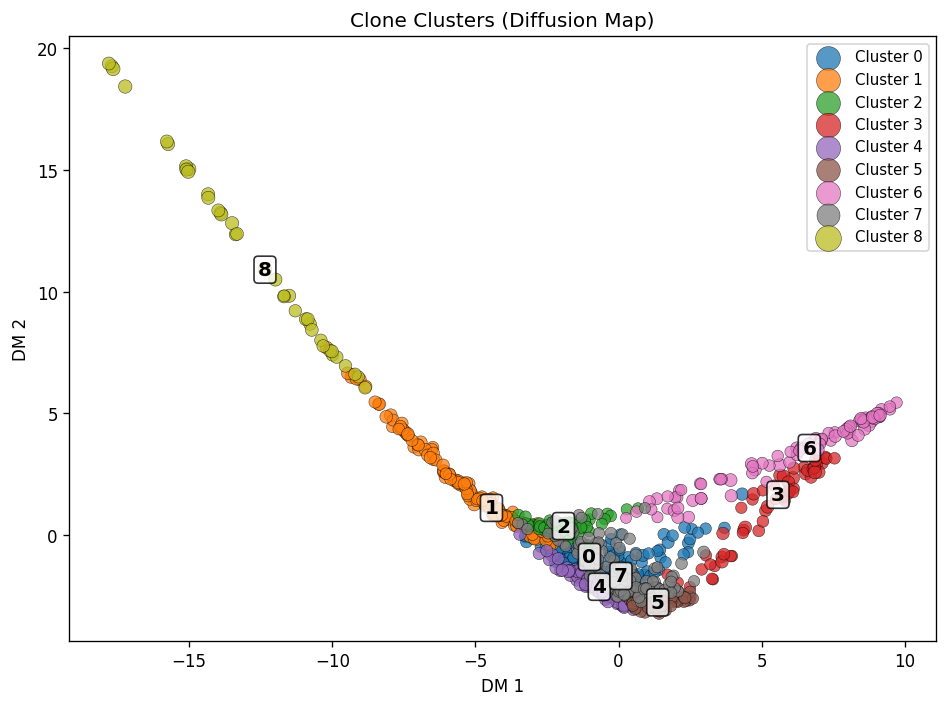

In [14]:
# Clone diffusion map colored by cluster
fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(clone_cluster["cluster"].unique()):
    mask = clone_cluster["cluster"] == c
    ax.scatter(
        clone_dm.loc[mask.values, "dm1"],
        clone_dm.loc[mask.values, "dm2"],
        s=np.log2(clone_cluster.loc[mask, "mass"] + 1) * 10,
        alpha=0.75, edgecolors="black", linewidths=0.3,
        label=f"Cluster {c}"
    )

# Add cluster center labels
for c in sorted(clone_cluster["cluster"].unique()):
    mask = clone_cluster["cluster"] == c
    cx = clone_dm.loc[mask.values, "dm1"].median()
    cy = clone_dm.loc[mask.values, "dm2"].median()
    ax.annotate(str(c), (cx, cy), fontsize=12, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

ax.legend(markerscale=2, fontsize=9, loc="best")
ax.set_xlabel("DM 1")
ax.set_ylabel("DM 2")
ax.set_title("Clone Clusters (Diffusion Map)")
plt.tight_layout()
plt.show()


Lineages with multiple timepoints: 106


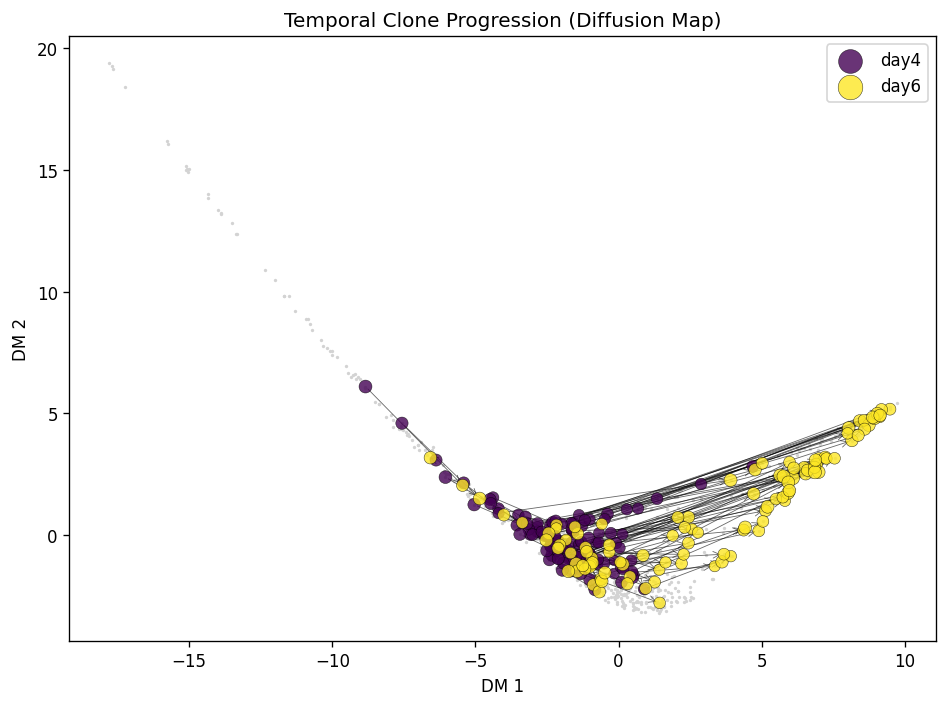

In [15]:
# Temporal arrows on diffusion map
# Parse lineage and timepoint from clone names (e.g., "Lineage-100-4" -> lineage="Lineage-100", time="day4")
clone_info = clone_cluster.copy()
clone_info["lineage"] = clone_info["clone"].apply(lambda x: x[:x.rfind("-")])
clone_info["time"] = clone_info["clone"].apply(lambda x: "day" + x[x.rfind("-")+1:])

# Find lineages present at multiple timepoints
lineage_times = clone_info.groupby("lineage")["time"].nunique()
multi_time = lineage_times[lineage_times > 1].index
print(f"Lineages with multiple timepoints: {len(multi_time)}")

# Build arrows: for each multi-time lineage, connect earlier to later clone
arrows = []
for lin in multi_time:
    sub = clone_info[clone_info["lineage"] == lin].sort_values("time")
    clones = sub["clone"].values
    for k in range(len(clones) - 1):
        arrows.append((clones[k], clones[k+1]))

fig, ax = plt.subplots(figsize=(8, 6))

# Background: all clones in grey
ax.scatter(clone_dm["dm1"], clone_dm["dm2"], s=1, c="lightgrey", zorder=1)

# Foreground: clones involved in temporal links, colored by time
temporal_clones = clone_info[clone_info["lineage"].isin(multi_time)]
time_colors = {"day4": "#440154", "day6": "#fde725"}  # viridis endpoints
for t in sorted(temporal_clones["time"].unique()):
    tmask = temporal_clones["time"] == t
    tclones = temporal_clones.loc[tmask, "clone"].values
    ax.scatter(
        clone_dm.loc[tclones, "dm1"], clone_dm.loc[tclones, "dm2"],
        s=np.log2(temporal_clones.loc[tmask, "mass"].values + 1) * 10,
        edgecolors="black", linewidths=0.3, alpha=0.8,
        label=t, c=time_colors.get(t, "grey"), zorder=3
    )

# Draw arrows
for start, end in arrows:
    x0, y0 = clone_dm.loc[start, "dm1"], clone_dm.loc[start, "dm2"]
    x1, y1 = clone_dm.loc[end, "dm1"], clone_dm.loc[end, "dm2"]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", lw=0.5, color="black", alpha=0.6),
                zorder=2)

ax.legend(markerscale=2, fontsize=10)
ax.set_xlabel("DM 1")
ax.set_ylabel("DM 2")
ax.set_title("Temporal Clone Progression (Diffusion Map)")
plt.tight_layout()
plt.show()


### 3.3 Clone MDS Embedding

Pre-computed MDS coordinates for additional visualization.

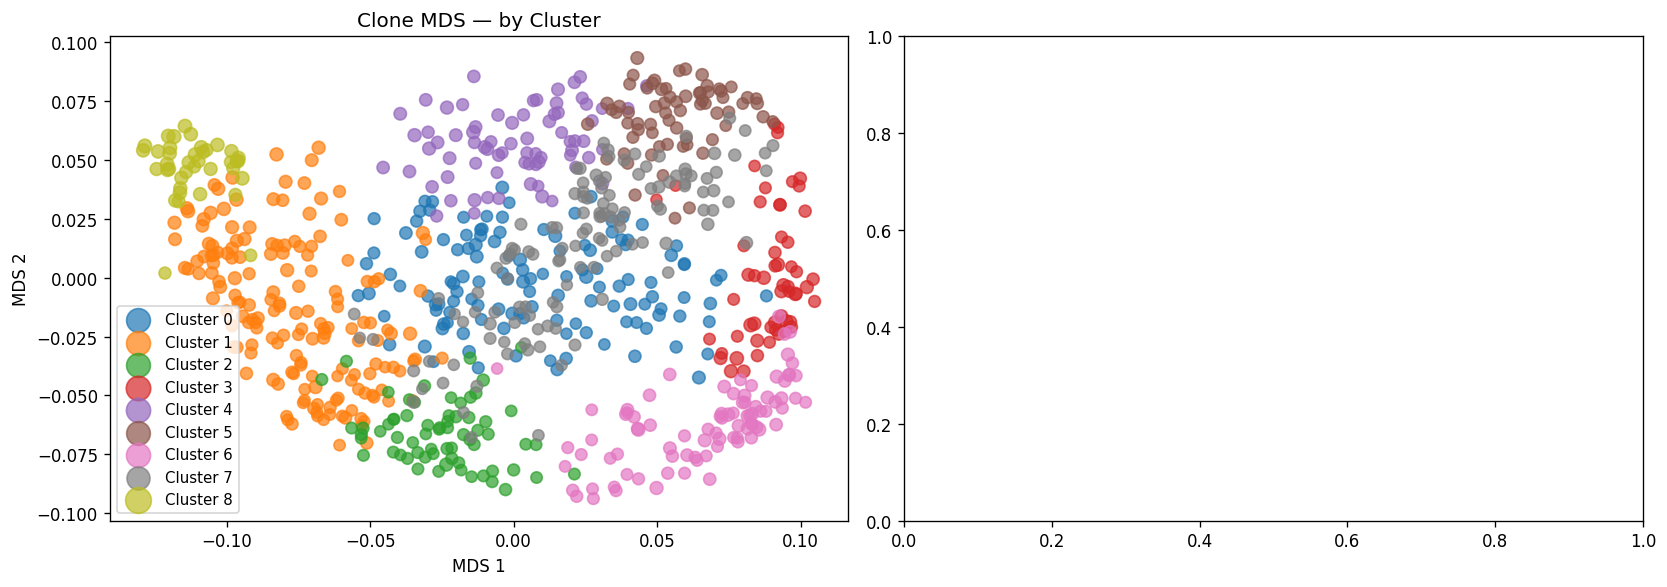

In [16]:
# Load MDS embedding of clone distances
clone_embedding = pd.read_csv(f"{DATA_DIR}/clone_mds.tsv", sep="\t", header=0, index_col=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by cluster
for c in sorted(clone_cluster["cluster"].unique()):
    sub_idx = clone_cluster["cluster"] == c
    axes[0].scatter(
        clone_embedding.iloc[sub_idx.values, 0],
        clone_embedding.iloc[sub_idx.values, 1],
        s=np.log2(clone_cluster.loc[sub_idx, "mass"] + 1) * 10,
        alpha=0.7, label=f"Cluster {c}"
    )
axes[0].legend(markerscale=2, fontsize=9)
axes[0].set_title("Clone MDS — by Cluster")
axes[0].set_xlabel("MDS 1")
axes[0].set_ylabel("MDS 2")

# Color by timepoint composition
if "time" in cell_meta.columns:
    timepoints = sorted(cell_meta["time"].dropna().unique())
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for t, color in zip(timepoints, colors):
        # Compute fraction of each clone's cells from this timepoint
        time_cells = cell_meta["time"] == t
        time_frac = np.zeros(len(clone_cluster))
        for ci, cn in enumerate(clone_names):
            clone_cells = cell_meta["clone"] == cn
            total = clone_cells.sum()
            if total > 0:
                time_frac[ci] = (clone_cells & time_cells).sum() / total
        axes[1].scatter(
            clone_embedding.iloc[:, 0], clone_embedding.iloc[:, 1],
            s=time_frac * 50 + 1, alpha=0.5, c=color, label=f"Time {t}"
        )
    axes[1].legend(markerscale=2, fontsize=9)
    axes[1].set_title("Clone MDS — by Timepoint")
    axes[1].set_xlabel("MDS 1")
    axes[1].set_ylabel("MDS 2")

plt.tight_layout()
plt.show()

## 4. Clone-Level Pseudotime

Compute diffusion pseudotime at the clone level, then propagate to cells.

In [17]:
clone_t = ct.clone_dpt(
    clone_embedding, cell_meta,
    clone_col="clone", cluster_col="cluster",
    start_cluster="0", k=10, dpt_k=30
)

clone_cluster["dpt"] = clone_t
print(f"Clone pseudotime range: [{clone_t.min():.4f}, {clone_t.max():.4f}]")

Clone pseudotime range: [0.0000, 1.0000]


/Users/yizhouw/Desktop/packages/Clonotrace_python/clonotrace/pseudotime.py:231: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


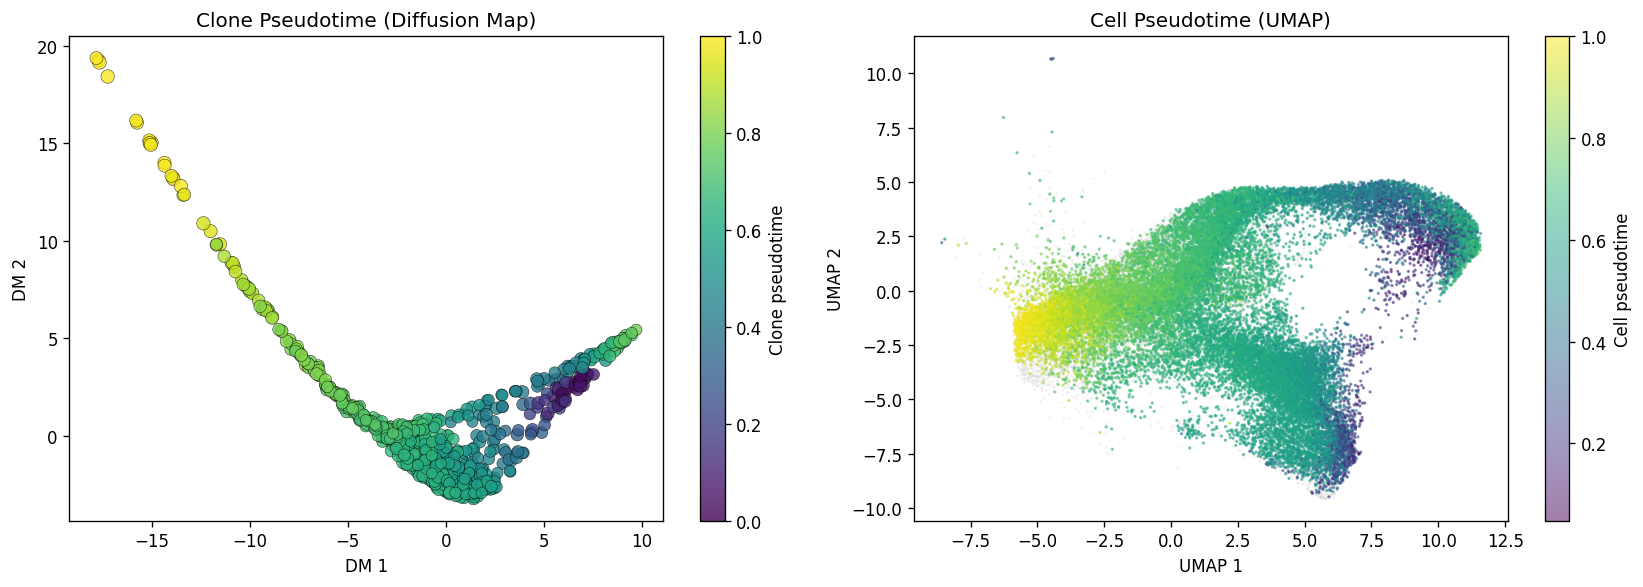

In [18]:
# Smooth pseudotime to cell level: cell_t = cell_clone_prob @ clone_t
cell_meta["cell_t"] = np.nan
cell_t = cell_clone_prob @ clone_t
cell_meta.loc[filtered_cells, "cell_t"] = cell_t

# Clone pseudotime on diffusion map + Cell pseudotime on UMAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clone-level pseudotime on diffusion map
sc1 = axes[0].scatter(
    clone_dm["dm1"], clone_dm["dm2"],
    c=clone_t, cmap="viridis",
    s=np.log2(clone_cluster["mass"] + 1) * 10,
    alpha=0.8, edgecolors="black", linewidths=0.3
)
plt.colorbar(sc1, ax=axes[0], label="Clone pseudotime")
axes[0].set_title("Clone Pseudotime (Diffusion Map)")
axes[0].set_xlabel("DM 1")
axes[0].set_ylabel("DM 2")

# Cell-level pseudotime on UMAP
has_t = cell_meta["cell_t"].notna()
axes[1].scatter(umap["umap_1"], umap["umap_2"], c="lightgrey", s=0.5, alpha=0.2)
sc2 = axes[1].scatter(
    umap["umap_1"][has_t], umap["umap_2"][has_t],
    c=cell_meta.loc[has_t, "cell_t"], cmap="viridis", s=1, alpha=0.5
)
plt.colorbar(sc2, ax=axes[1], label="Cell pseudotime")
axes[1].set_title("Cell Pseudotime (UMAP)")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()


## 5. Profile Projection

Map clone clusters back to individual cells as **clone profiles**.

In [19]:
# Build clone-to-profile mapping matrix
clone_profile_df = clone_cluster[["clone", "cluster"]].copy()
clone_profile_df["flag"] = 1
clone_profile = ct.long2sparse(
    clone_profile_df, row_names_from="clone",
    col_names_from="cluster", values_from="flag"
)

# Reindex clone_profile rows to match clone_names order
row_idx = [clone_profile.rownames.index(c) for c in clone_names]
clone_profile_reindexed = clone_profile[row_idx, :]

# Cell × profile probability matrix
cell_profile_prob = cell_clone_prob @ clone_profile_reindexed

# Hard profile assignment (max probability > 0.5)
cell_meta["profile"] = np.nan
prob_dense = np.array(cell_profile_prob.todense()) if sp.issparse(cell_profile_prob) else cell_profile_prob
max_prob = prob_dense.max(axis=1)
profile_labels = prob_dense.argmax(axis=1)
assigned = max_prob > 0.5
cell_meta.loc[filtered_cells[assigned], "profile"] = profile_labels[assigned]

print(f"Cells with profile assignment: {assigned.sum()} / {len(filtered_cells)}")
print(f"Profile distribution: {pd.Series(profile_labels[assigned]).value_counts().to_dict()}")


Cells with profile assignment: 24980 / 27516
Profile distribution: {1: 5878, 6: 3257, 0: 3186, 8: 2679, 4: 2438, 7: 2330, 3: 2049, 5: 1736, 2: 1427}


/var/folders/95/_m49_cfn61qccl6yr_9f6ptm0000gp/T/ipykernel_92421/1058171338.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


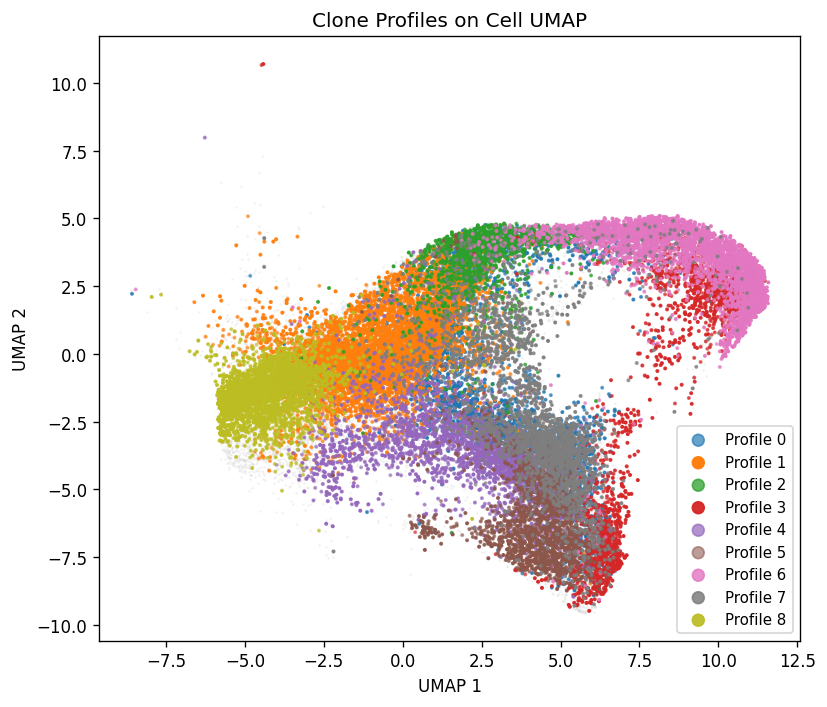

In [20]:
# Visualize profiles on cell UMAP
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(umap["umap_1"], umap["umap_2"], c="lightgrey", s=0.5, alpha=0.2)

has_profile = cell_meta["profile"].notna()
profiles = cell_meta.loc[has_profile, "profile"].astype(int)
cmap = plt.cm.get_cmap("tab10")

for p in sorted(profiles.unique()):
    pmask = profiles == p
    idx = has_profile[has_profile].index[pmask]
    # Alpha proportional to max profile probability
    prob_vals = prob_dense[np.where(has_profile[filtered_cells].values)[0][pmask], p]
    ax.scatter(
        umap.loc[idx, "umap_1"], umap.loc[idx, "umap_2"],
        c=[cmap(p)] * len(idx), s=2,
        alpha=np.clip(prob_vals, 0.2, 1.0),
        label=f"Profile {p}"
    )

ax.legend(markerscale=5, fontsize=9)
ax.set_title("Clone Profiles on Cell UMAP")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## 6. Clone-Weighted Cell Embedding

Combine cell kNN and clone kNN into a joint embedding that captures clone-level heterogeneity boundaries.

In [21]:
# Compute co-embedding distance matrix
coembed_dist = cell_clone_coembed(
    cell_embedding=pca.loc[filtered_cells].values,
    clone_embedding=clone_embedding.values,
    cell_clone_prob=cell_clone_prob,
    cell_k=30, clone_k=15
)

# UMAP from the co-embedding kNN
coembed_umap, coembed_kept = umap_from_knn(coembed_dist, n_neighbors=5, seed=512)
coembed_cells = filtered_cells[coembed_kept]
print(f"Co-embedding UMAP: {coembed_umap.shape}")
print(f"Cells kept after network filtering: {coembed_kept.sum()} / {len(filtered_cells)}")


/Users/yizhouw/Desktop/packages/Clonotrace_python/clonotrace/coembed.py:127: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(20, "dis")))


/Users/yizhouw/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/yizhouw/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Co-embedding UMAP: (26761, 2)
Cells kept after network filtering: 26761 / 27516


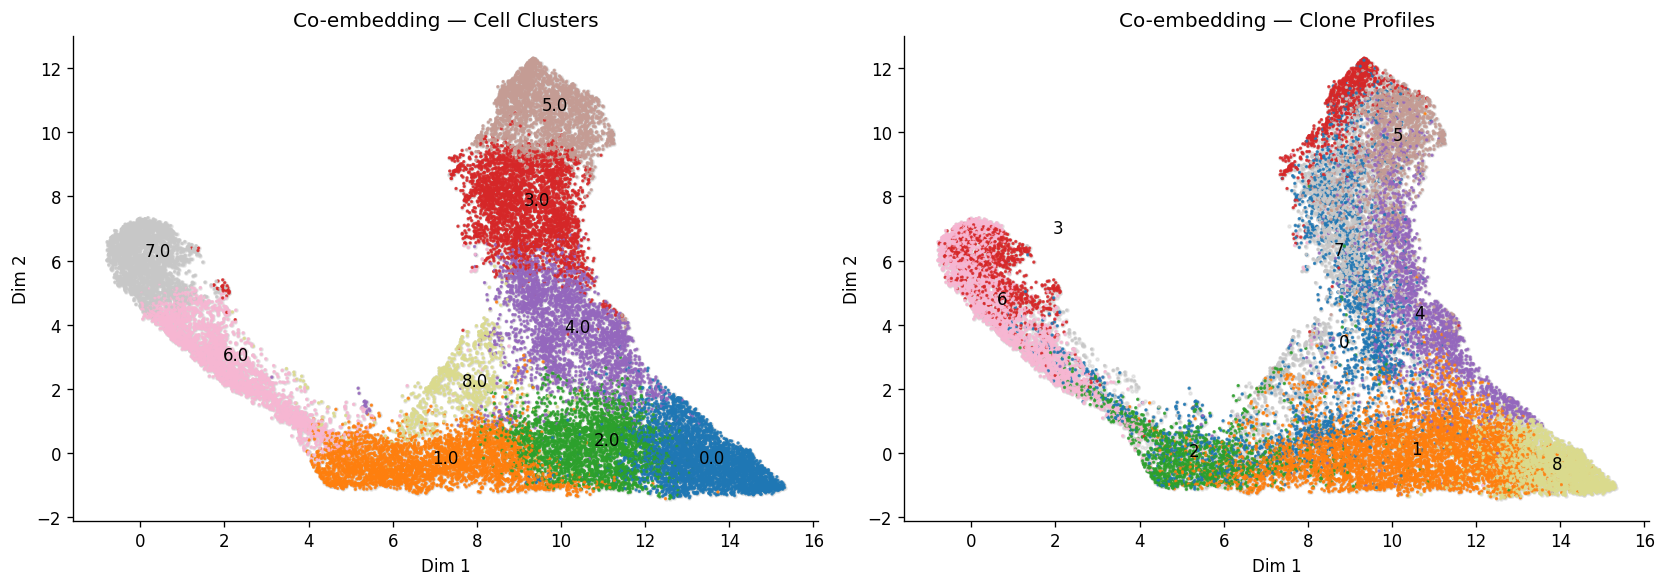

In [22]:
# Visualize co-embedding colored by cluster and profile
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meta_coembed = cell_meta.loc[coembed_cells].copy()

coembed_coords = pd.DataFrame({
    "umap_1": coembed_umap["umap_1"].values,
    "umap_2": coembed_umap["umap_2"].values
}, index=coembed_cells)

dimplot(coembed_coords, meta_coembed, color_by="cluster", ax=axes[0], s=1)
axes[0].set_title("Co-embedding — Cell Clusters")

if "profile" in meta_coembed.columns and meta_coembed["profile"].notna().any():
    dimplot(coembed_coords, meta_coembed, color_by="profile", ax=axes[1], s=1)
    axes[1].set_title("Co-embedding — Clone Profiles")
else:
    dimplot(coembed_coords, meta_coembed, color_by="Cell.type.annotation", ax=axes[1], s=1)
    axes[1].set_title("Co-embedding — Cell Types")

plt.tight_layout()
plt.show()


## 7. Profile Enrichment in Cell Clusters

Permutation test: which clone profiles are enriched in which cell clusters?

In [23]:
# Convert cell_profile_prob to dense for enrichment test
cell_profile_dense = prob_dense  # already computed as dense in profile assignment cell

enrich = ct.cluster_profile_enrich(
    cell_profile_dense,
    cell_meta.loc[filtered_cells, "cluster"].values,
    permute_n=1000
)

print("Enrichment results:")
for key in enrich:
    print(f"  {key}: shape {np.array(enrich[key]).shape}")


Enrichment results:
  prob: shape (9, 9)
  pval: shape (9, 9)


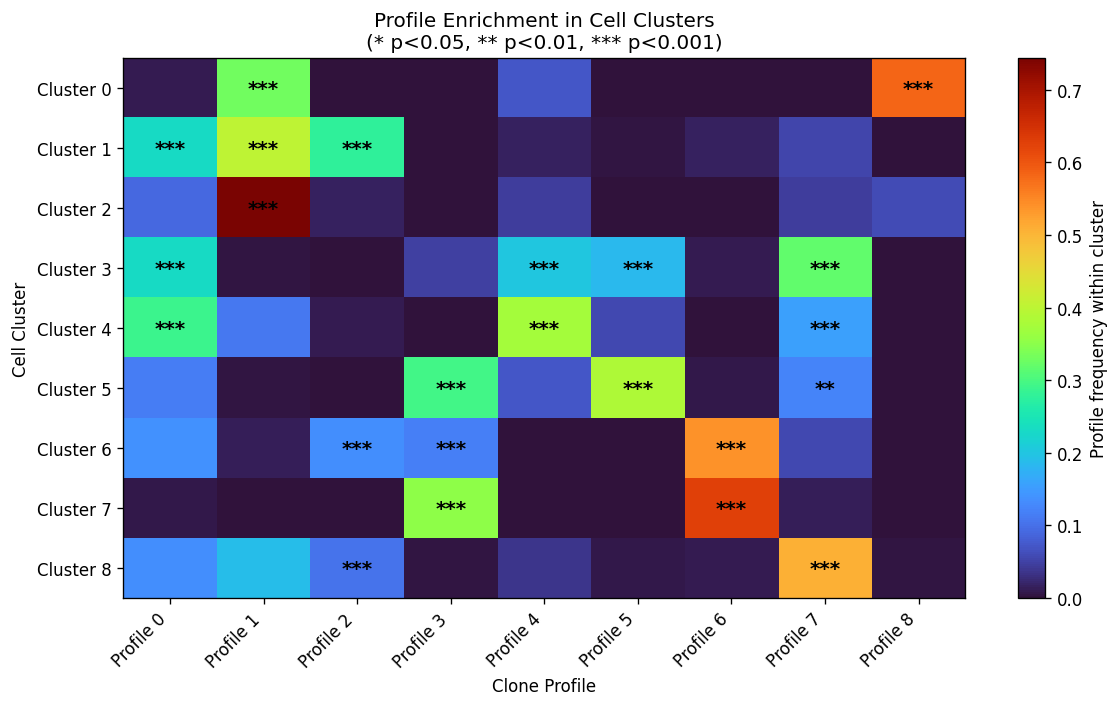

In [24]:
# Enrichment heatmap with significance annotations
prob = np.array(enrich["prob"])
pval = np.array(enrich["pval"])

# Normalize within each cluster (row) to get frequency, matching R
row_sums = prob.sum(axis=1, keepdims=True)
row_sums = np.maximum(row_sums, 1e-12)
freq = prob / row_sums

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(freq, cmap="turbo", aspect="auto")
plt.colorbar(im, ax=ax, label="Profile frequency within cluster")

# Add significance stars
for i in range(freq.shape[0]):
    for j in range(freq.shape[1]):
        p = pval[i, j]
        if p < 0.001:
            star = "***"
        elif p < 0.01:
            star = "**"
        elif p < 0.05:
            star = "*"
        else:
            star = ""
        ax.text(j, i, star, ha="center", va="center", fontsize=12, fontweight="bold")

clusters = sorted(cell_meta.loc[filtered_cells, "cluster"].unique())
ax.set_xticks(range(freq.shape[1]))
ax.set_xticklabels([f"Profile {i}" for i in range(freq.shape[1])], rotation=45, ha="right")
ax.set_yticks(range(freq.shape[0]))
ax.set_yticklabels([f"Cluster {c}" for c in clusters])
ax.set_xlabel("Clone Profile")
ax.set_ylabel("Cell Cluster")
ax.set_title("Profile Enrichment in Cell Clusters\n(* p<0.05, ** p<0.01, *** p<0.001)")

plt.tight_layout()
plt.show()


## 8. Profile-Specific Differential Expression

Identify genes differentially expressed in a specific clone profile within a cell cluster.

In [25]:
# Find DEGs for the first profile in a cluster where it's enriched
best_i, best_j = np.unravel_index(np.argmin(pval), pval.shape)
target_cluster = clusters[best_i]
target_profile = best_j
print(f"Testing DEG: Profile {target_profile} in Cluster {target_cluster} (p={pval[best_i, best_j]:.4f})")

# Prepare cell_profile_prob as DataFrame with proper index and column names
cell_profile_prob_df = pd.DataFrame(
    prob_dense, 
    index=filtered_cells,
    columns=[str(i) for i in range(prob_dense.shape[1])]
)

# Prepare exprs as DataFrame (genes x cells)
exprs_df = pd.DataFrame(
    exprs.toarray() if sp.issparse(exprs) else exprs,
    index=gene_names,
    columns=cell_names_exprs
)

DEG_result = ct.profile_cluster_DEG(
    profile=str(target_profile), cluster=target_cluster,
    exprs=exprs_df, cell_meta=cell_meta,
    cell_profile_prob=cell_profile_prob_df,
    permute_n=50
)

if DEG_result is not None:
    stat = DEG_result["stat"]
    sig_genes = stat[stat["padj"] < 0.05]
    print(f"Significant DEGs (padj < 0.05): {len(sig_genes)}")
    print("Top 10 DEGs:")
    print(sig_genes.head(10).to_string())
else:
    print("No DEG results (profile-cluster pair may have too few cells)")


Testing DEG: Profile 1 in Cluster 0 (p=0.0000)


/Users/yizhouw/Desktop/packages/Clonotrace_python/clonotrace/profile_deg.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (df.groupby("bin")[["target", "control"]]


Significant DEGs (padj < 0.05): 39
Top 10 DEGs:
              stat          pval  mean_diff     cohen     pcali  padj
Ap3s1    27.737417  9.756380e-23  -0.380054 -0.177892  0.000000  0.00
Bcl11a   23.218281  5.485089e-19  -0.115958 -0.151715  0.000000  0.00
Calr     20.796099  5.625137e-17   0.762310  0.248463  0.000000  0.00
Ccnd1    30.311142  7.181796e-25  -0.091561 -0.392762  0.000000  0.00
Cd28     26.161098  1.980463e-21  -0.053859 -0.173718  0.000000  0.00
Cd74     25.437229  7.895807e-21   0.037697  0.092926  0.000000  0.00
Cmpk2    43.802516  5.316492e-36   0.405003  0.649146  0.000000  0.00
Ctsg     43.986475  3.754549e-36  -0.263399 -0.165451  0.000000  0.00
Cyp11a1  16.140960  4.093110e-13   0.174378  0.446471  0.000004  0.04
Dlk1     22.094120  4.704132e-18   8.425636  1.870843  0.000000  0.00


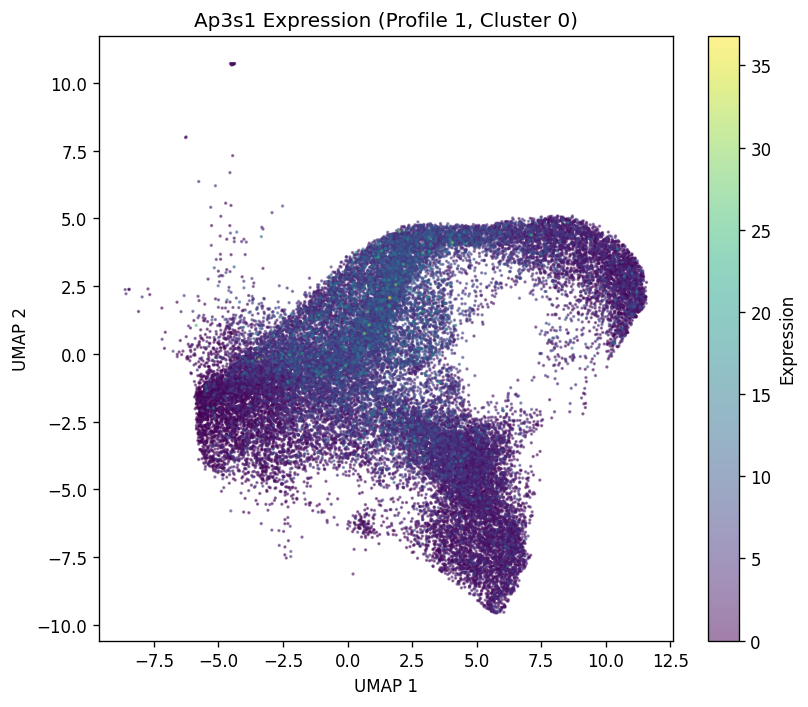

In [26]:
# Visualize top DEG on UMAP
if DEG_result is not None and len(DEG_result) > 0:
    top_gene = sig_genes.index[0] if hasattr(sig_genes.index, '__len__') else sig_genes.iloc[0].name
    if isinstance(top_gene, int) or (isinstance(top_gene, str) and top_gene.isdigit()):
        gene_idx = int(top_gene)
        top_gene_name = gene_names[gene_idx] if gene_idx < len(gene_names) else f"Gene {gene_idx}"
    else:
        top_gene_name = str(top_gene)
        gene_idx = gene_names.index(top_gene_name) if top_gene_name in gene_names else None

    if gene_idx is not None:
        expr_vals = np.array(exprs[gene_idx, :].todense()).ravel()
        # Map to cell_meta order
        expr_mapped = pd.Series(expr_vals, index=cell_names_exprs)
        expr_final = expr_mapped.reindex(cell_meta.index).fillna(0).values

        fig, ax = plt.subplots(figsize=(7, 6))
        order = np.argsort(expr_final)  # plot high values on top
        sc = ax.scatter(
            umap["umap_1"].values[order], umap["umap_2"].values[order],
            c=expr_final[order], cmap="viridis", s=1, alpha=0.5
        )
        plt.colorbar(sc, ax=ax, label="Expression")
        ax.set_title(f"{top_gene_name} Expression (Profile {target_profile}, Cluster {target_cluster})")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        plt.tight_layout()
        plt.show()

## Summary

This notebook demonstrated the complete Clonotrace pipeline:

1. **Label spreading** — Propagated sparse clone barcodes across a cell kNN graph
2. **Clone distance** — Loaded pre-computed transcriptomic distances between clones
3. **Clone clustering** — Grouped clones by transcriptomic similarity (Louvain)
4. **Pseudotime** — Inferred clone-level developmental ordering via diffusion pseudotime
5. **Profile projection** — Mapped clone clusters back to cells as clone profiles
6. **Co-embedding** — Combined cell and clone information for joint visualization
7. **Enrichment** — Identified profile-cluster associations via permutation test
8. **DEG analysis** — Found profile-specific differentially expressed genes

For more details, see the [R vignette](https://github.com/your-repo/Clonotrace) and the Clonotrace paper.